# **Simulación Acoplada de Difusión de Hidrógeno y Respuesta Mecánica en Cilindros mediante Diferencias Finitas Implícitas**

## 👤 Juan Carlos Vega


Computer Sciences PhD Student

**IA para Energías Renovables**  
Universidad de los Andes,

2025

# Simulación de Difusión de Hidrógeno y Esfuerzos en un Cilindro mediante Diferencias Finitas Implícitas

Este código implementa un modelo numérico para simular la **difusión de hidrógeno (H₂)** en un cilindro hueco y calcular los **esfuerzos y deformaciones** inducidos en el material a lo largo del tiempo.  
El método empleado es **Diferencias Finitas Implícitas** para la ecuación de difusión radial, junto con un modelo de **elasticidad lineal** para evaluar las respuestas mecánicas del cilindro.

## Objetivos
- Resolver la **ecuación de difusión de Fick** en coordenadas cilíndricas considerando condiciones de frontera fijas en las superficies interna y externa.
- Calcular **flujos radiales de hidrógeno** a lo largo del espesor del cilindro y en el tiempo.
- Determinar **desplazamientos, esfuerzos y deformaciones** asociados a la difusión y a la expansión volumétrica química (efecto de la concentración en el material).
- Visualizar los resultados en gráficos que permitan el análisis temporal y espacial.

## Características del modelo
- **Dominio**: Cilindro hueco definido por radios interno (`Ri`) y externo (`Ro`).
- **Propiedades físicas**: difusividad `D`, módulo de Young `E`, coeficiente de Poisson `ν`, coeficiente de expansión volumétrica química `Ω`, presión interna `p_in`.
- **Discretización**:
  - Espacial: mallado radial con `n` nodos.
  - Temporal: esquema implícito con `nt` pasos de tiempo.
- **Métodos numéricos**:
  - Resolución de sistemas lineales tridiagonales/banda mediante `solve_banded` de SciPy.
  - Esquema implícito estable para la difusión.
  - Elasticidad lineal en coordenadas cilíndricas para esfuerzos y deformaciones.
---


In [19]:
# =============================================
# Simulación de difusión de H2 y esfuerzos en cilindro
# Método de Diferencias Finitas Implícitas (FD)
# Adaptado para Google Colab - Ejecución directa
# =============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
import time

## Difusión en el contexto de la simulación

**Definición**  
La difusión es el proceso físico mediante el cual las partículas (átomos, moléculas o iones) se desplazan dentro de un medio como resultado de gradientes de concentración, temperatura o potencial químico.  
En este caso, se modela la **difusión de hidrógeno (H₂)** a través del material de un cilindro hueco, impulsada por la diferencia de concentración entre su superficie interna y externa.

---

**Formulación matemática**  
El fenómeno está descrito por las **Leyes de Fick** en coordenadas cilíndricas:

1. **Primera Ley de Fick** (flujo instantáneo):
\[
J_r = -D \frac{\partial C}{\partial r}
\]
donde:
- \( J_r \): flujo másico radial \([ \text{mol}/\text{m}^2 \cdot \text{s} ]\),
- \( D \): coeficiente de difusión \([ \text{m}^2/\text{s} ]\),
- \( C \): concentración \([ \text{mol}/\text{m}^3 ]\),
- \( r \): coordenada radial.

2. **Segunda Ley de Fick** (evolución temporal de la concentración):
\[
\frac{\partial C}{\partial t} = \frac{1}{r} \frac{\partial}{\partial r} \left( r D \frac{\partial C}{\partial r} \right)
\]

---

**Implementación en el modelo**  
- **Dominio**: cilindro hueco con radio interno \( R_i \) y radio externo \( R_o \).
- **Condiciones de frontera**:
  - Cara interna: concentración fija \( C_\text{in} \).
  - Cara externa: concentración fija \( C_\text{out} \).
- **Condición inicial**: concentración uniforme \( C_0 \) (en este caso, cero).

El gradiente de concentración entre las fronteras produce un **flujo neto de hidrógeno** hacia el interior del material.  
Con el tiempo, el sistema evoluciona hacia un **estado estacionario**, donde el perfil de concentración es constante en el tiempo, aunque el flujo pueda mantenerse si \( C_\text{in} \neq C_\text{out} \).

Este proceso es clave en la ingeniería de materiales, ya que la presencia y migración de hidrógeno puede provocar efectos como fragilización, expansión volumétrica o alteraciones en las propiedades mecánicas.


## Permeabilidad en el contexto de la simulación

**Definición**  
La permeabilidad es la capacidad que tiene un material para permitir el paso de una sustancia a través de él, ya sea un líquido, un gas o incluso calor o campos magnéticos, dependiendo del contexto.  
En el caso que nos ocupa, se refiere a la **capacidad del material del cilindro para dejar pasar hidrógeno (H₂)** desde un lado hasta el otro, combinando tanto el proceso de difusión como el efecto de la solubilidad del gas en el sólido.

---

**Formulación matemática**  
Para un gas que se difunde a través de un sólido, la permeabilidad \( P \) puede expresarse como:

\[
P = D \cdot S
\]
donde:
- \( P \): permeabilidad del material \([ \text{mol} \cdot \text{m} / (\text{m}^2 \cdot \text{s} \cdot \text{Pa}) ]\),
- \( D \): coeficiente de difusión \([ \text{m}^2/\text{s} ]\),
- \( S \): solubilidad del gas en el material \([ \text{mol} / (\text{m}^3 \cdot \text{Pa}) ]\).

El flujo de masa a través de un material permeable bajo un gradiente de presión o concentración se describe por:

\[
J = P \cdot \frac{\Delta p}{L}
\]
donde:
- \( J \): flujo másico \([ \text{mol} / (\text{m}^2 \cdot \text{s}) ]\),
- \( \Delta p \): diferencia de presión entre las dos caras del material \([ \text{Pa} ]\),
- \( L \): espesor del material \([ \text{m} ]\).

---

**Implementación en el modelo**  
En la simulación, la permeabilidad no se calcula explícitamente, pero está implícita en el proceso de difusión:
- El valor de \( D \) representa la rapidez con la que el hidrógeno se mueve dentro del material.
- La condición de frontera interna fija \( C_\text{in} \) y la externa fija \( C_\text{out} \) establecen el gradiente que impulsa el flujo.
- Si se conociera la solubilidad \( S \) del hidrógeno en el material, podría calcularse directamente \( P \) y relacionar la simulación con mediciones experimentales.

---

**Importancia**  
La permeabilidad es un parámetro clave en ingeniería de materiales, especialmente para:
- Evaluar la resistencia de barreras contra gases.
- Diseñar recipientes o tuberías que contengan hidrógeno de forma segura.
- Predecir fugas y pérdida de rendimiento en sistemas presurizados.


In [20]:
# ==============================
# 1. Parámetros físicos y de simulación
# ==============================
Ro = 2.0e-2        # radio externo [m]
Ri = Ro - 3.0e-3   # radio interno [m]
Cin = 0.1          # concentración en la cara interna
Cout = 0.0         # concentración en la cara externa
D = 1.0e-8         # difusividad [m²/s]
E = 10e9           # módulo de Young [Pa]
nu = 0.3           # coeficiente de Poisson
Omega = 5.0e-3     # coef. expansión volumétrica química
C0 = 0.0           # concentración inicial
pin = 400.0e3      # presión interna [Pa]

# Por rapidez en Colab, puedes reducir n para test rápido; para resultados finales sube otra vez.
n = 500            # nodos (2000 es el valor original; usar 500 para debug/visualizar rápido)
dr = (Ro - Ri) / (n - 1)

S = 60 * 60        # segundos por hora (factor de conversión)
t_end_hours = 5.0  # tiempo total en horas
nt = 500           # pasos temporales (usa 1000/2000 en runs definitivos)
dt_hours = t_end_hours / (nt - 1)
dt = dt_hours * S  # paso temporal en segundos (¡USAR dt en segundos!)

## Justificación y origen de los parámetros físicos y de simulación

En esta sección se definen los parámetros que controlan tanto las propiedades físicas del problema como la configuración numérica de la simulación. La elección de estos valores se basa en datos típicos para materiales metálicos y en la necesidad de equilibrar precisión física con eficiencia computacional.

---

### Parámetros geométricos
- **`Ro = 2.0e-2` [m]**  
  Radio externo del cilindro hueco. Corresponde a 20 mm, un tamaño típico para probetas de laboratorio o secciones de tuberías pequeñas.
  
- **`Ri = Ro - 3.0e-3` [m]**  
  Radio interno del cilindro, definido como el radio externo menos el espesor de la pared (3 mm). Este espesor permite un tiempo característico de difusión en el rango de minutos–horas para valores de difusividad típicos.

---

### Condiciones de frontera de concentración
- **`Cin = 0.1`**  
  Concentración de hidrógeno en la superficie interna. Representa una concentración normalizada o fracción molar fija que simula una atmósfera rica en hidrógeno en el interior del cilindro.
  
- **`Cout = 0.0`**  
  Concentración de hidrógeno en la superficie externa. Simula un ambiente libre de hidrógeno o en el que el gas se elimina inmediatamente al llegar.

---

### Propiedades del material
- **`D = 1.0e-8` [m²/s]**  
  Coeficiente de difusión del hidrógeno en metales como aceros al carbono o aleaciones ligeras a temperatura ambiente. Este valor proviene de datos experimentales en literatura especializada.

- **`E = 10e9` [Pa]**  
  Módulo de Young del material, aquí aproximado a 10 GPa. Aunque los aceros suelen tener valores más altos (~200 GPa), este valor reducido puede representar materiales menos rígidos o ajustarse para observar efectos mecánicos en la simulación.

- **`nu = 0.3`**  
  Coeficiente de Poisson típico para metales y aleaciones, que describe la relación entre deformación transversal y longitudinal.

- **`Omega = 5.0e-3`**  
  Coeficiente de expansión volumétrica química, que cuantifica la expansión del material por unidad de concentración de hidrógeno. Este valor se toma de estudios sobre expansión inducida por absorción de gases en metales.

- **`C0 = 0.0`**  
  Concentración inicial uniforme de hidrógeno en el cilindro, asumiendo que antes de la exposición el material estaba libre del gas.

- **`pin = 400.0e3` [Pa]**  
  Presión interna aplicada (400 kPa). Representa la carga mecánica interna en recipientes presurizados o tuberías.

---

### Parámetros numéricos
- **`n = 500`**  
  Número de nodos en la discretización radial. Para simulaciones rápidas en Google Colab se reduce respecto al valor original (2000), manteniendo un compromiso entre resolución espacial y velocidad.

- **`dr = (Ro - Ri) / (n - 1)`**  
  Paso espacial radial, calculado automáticamente a partir del número de nodos y la geometría.

- **`S = 60 * 60`**  
  Factor de conversión de horas a segundos, necesario para trabajar en unidades del Sistema Internacional (SI).

- **`t_end_hours = 5.0`**  
  Tiempo total de simulación en horas. Este intervalo permite observar la evolución desde el estado inicial hasta la estabilización de la concentración.

- **`nt = 500`**  
  Número de pasos de tiempo. Igual que con `n`, se ajusta para ejecución rápida; valores más altos (1000–2000) se usan para resultados definitivos.

- **`dt_hours = t_end_hours / (nt - 1)`**  
  Paso de tiempo en horas.

- **`dt = dt_hours * S`**  
  Paso de tiempo en segundos (unidad utilizada en los cálculos de difusión).

---



In [21]:
# ==============================
# 1. Preasignación de matrices y condición inicial
# ==============================
r = np.linspace(Ri, Ro, n)
tvec = np.linspace(0, t_end_hours, nt)  # para graficas en horas

H = np.zeros((n, nt))
Hflux = np.zeros((n, nt))
HDisp = np.zeros((n, nt))
HStress_r = np.zeros((n, nt))
HStress_t = np.zeros((n, nt))
HStrain_r = np.zeros((n, nt))
HStrain_t = np.zeros((n, nt))

# inicial condición
C_old = np.full(n, C0)
H[:, 0] = C_old

## Preasignación de matrices y condición inicial

En esta sección se preparan las estructuras de datos necesarias para almacenar la información que se generará durante la simulación.  
La **preasignación** (o preallocación) es una técnica utilizada para mejorar la eficiencia computacional, evitando que las matrices crezcan dinámicamente en cada iteración.

---

### Vectores espaciales y temporales
- **`r = np.linspace(Ri, Ro, n)`**  
  Crea un vector de posiciones radiales desde el radio interno `Ri` hasta el radio externo `Ro` con `n` nodos.  
  Esto define la discretización espacial de la simulación.

- **`tvec = np.linspace(0, t_end_hours, nt)`**  
  Crea un vector de tiempos en **horas** que se usará para graficar la evolución de las variables.  
  Va desde 0 hasta el tiempo total de simulación `t_end_hours` en `nt` pasos.

---

### Matrices para almacenamiento de resultados
Cada matriz tiene dimensiones `(n, nt)`, donde:
- `n` → número de nodos radiales.
- `nt` → número de pasos de tiempo.

Variables preasignadas:
- **`H`**: concentración de hidrógeno en cada nodo y tiempo.
- **`Hflux`**: flujo radial de hidrógeno.
- **`HDisp`**: desplazamiento radial del material.
- **`HStress_r`**: esfuerzo radial (\( \sigma_r \)).
- **`HStress_t`**: esfuerzo tangencial o circunferencial (\( \sigma_\theta \)).
- **`HStrain_r`**: deformación radial (\( \varepsilon_r \)).
- **`HStrain_t`**: deformación tangencial (\( \varepsilon_\theta \)).

---

### Condición inicial
- **`C_old = np.full(n, C0)`**  
  Vector que contiene la concentración inicial en todos los nodos.  
  `C0` es la concentración inicial definida en los parámetros físicos.

- **`H[:, 0] = C_old`**  
  Asigna la concentración inicial a todos los nodos en el tiempo \( t = 0 \).  
  Esto establece el estado de partida de la simulación antes de comenzar el proceso de difusión.

---

**Resumen**  
Este bloque asegura que todas las variables que se calcularán en el tiempo tengan memoria reservada desde el inicio, lo que mejora el rendimiento y facilita la organización de los resultados.


In [22]:
# ==============================
# 3. Montaje de matrices (coeficientes FD)
# Construcción explícita de las diagonales
# Usamos el esquema backward-Euler (implícito)
# Matriz: (-1/dt)*I + D * L_r  where L_r es el operador radial discretizado
# ==============================

# vectores tri-diagonales
lower = np.zeros(n)   # a_i multiplies C_{i-1}, defined for i>=1
diag = np.zeros(n)    # main diagonal
upper = np.zeros(n)   # c_i multiplies C_{i+1}, defined for i<=n-2

# precompute coeficientes espaciales para i=1..n-2 (interior)
for i in range(1, n-1):
    a_i = D * (1.0/dr**2 - 1.0/(2.0 * r[i] * dr))   # multiplies C_{i-1}
    b_i = -2.0 * D / dr**2                          # central Laplacian part
    c_i = D * (1.0/dr**2 + 1.0/(2.0 * r[i] * dr))   # multiplies C_{i+1}
    lower[i] = a_i
    diag[i] = b_i - 1.0/dt   # include time -1/dt term
    upper[i] = c_i

# boundaries: enforce Dirichlet C[0]=Cin, C[n-1]=Cout => rows become identity
diag[0] = 1.0
upper[0] = 0.0
lower[0] = 0.0

diag[-1] = 1.0
lower[-1] = 0.0
upper[-1] = 0.0

# For first and last interior columns we need proper positions:
# For solve_banded, A has shape (l+u+1, n) with l=u=1 here.
# Row 0 -> upper diag (A[0, j] = a_{j-1,j} = upper at column j)
# Row 1 -> main diag (A[1, j] = diag[j])
# Row 2 -> lower diag (A[2, j] = a_{j+1,j} = lower at column j)
# So we build banded_A accordingly.

# Build banded matrix A_banded
A_banded = np.zeros((3, n))
# main diag row
A_banded[1, :] = diag.copy()

# upper diag: put upper[0..n-2] at A_banded[0,1..n-1]
A_banded[0, 1:] = upper[1:]   # upper[1] corresponds to column=1 (connection 0<->1)
# lower diag: put lower[1..n-1] at A_banded[2,0..n-2]
A_banded[2, :-1] = lower[1:]  # lower[1] corresponds to column=0 (connection 1->0)

# quick sanity check (small prints)
print("Sanity: sum abs diag, upper, lower (sample):",
      np.sum(np.abs(A_banded[1, :])), np.sum(np.abs(A_banded[0, :])), np.sum(np.abs(A_banded[2, :])))

Sanity: sum abs diag, upper, lower (sample): 275576.9123333335 137802.989956818 137758.1167098488


## Montaje de matrices para el esquema de Diferencias Finitas Implícitas (Backward Euler)

En este bloque se construye la **matriz tridiagonal** que representa la discretización implícita de la ecuación de difusión en coordenadas cilíndricas.  
El método utilizado es **Backward Euler**, que es incondicionalmente estable para problemas de difusión y permite usar pasos de tiempo relativamente grandes.

---

### 1. Ecuación discretizada
El esquema implícito parte de la ecuación:

\[
\frac{C^{n+1} - C^{n}}{\Delta t} = D \cdot L_r \left( C^{n+1} \right)
\]

donde \( L_r \) es el operador laplaciano en coordenadas cilíndricas.  
Reorganizando, obtenemos:

\[
\left( -\frac{1}{\Delta t} I + D \cdot L_r \right) C^{n+1} = -\frac{1}{\Delta t} C^{n}
\]

---

### 2. Definición de diagonales
La ecuación anterior da lugar a una **matriz tridiagonal** con:
- `lower`: coeficientes subdiagonales (\( a_i \)) que multiplican \( C_{i-1} \).
- `diag`: diagonal principal (\( b_i \)) que multiplica \( C_i \).
- `upper`: coeficientes superdiagonales (\( c_i \)) que multiplican \( C_{i+1} \).

Para los nodos interiores \( i = 1 \dots n-2 \):

\[
\begin{aligned}
a_i &= D \left( \frac{1}{\Delta r^2} - \frac{1}{2 r_i \Delta r} \right) \\
b_i &= -\frac{2 D}{\Delta r^2} \quad \text{(parte central del laplaciano)} \\
c_i &= D \left( \frac{1}{\Delta r^2} + \frac{1}{2 r_i \Delta r} \right)
\end{aligned}
\]

La contribución de tiempo \(-1/\Delta t\) se suma a la diagonal principal.

---

### 3. Condiciones de frontera
Se aplican **condiciones de Dirichlet**:
- Nodo interno \( i = 0 \): \( C = C_\text{in} \)
- Nodo externo \( i = n-1 \): \( C = C_\text{out} \)

Esto se implementa haciendo que la fila correspondiente sea la identidad (1 en la diagonal, 0 en el resto), lo que fija el valor directamente.

---

### 4. Formato banda para `solve_banded`
SciPy utiliza un formato compacto para matrices banda:
- **Fila 0** → diagonal superior (`upper`)
- **Fila 1** → diagonal principal (`diag`)
- **Fila 2** → diagonal inferior (`lower`)

La matriz `A_banded` se construye colocando cada diagonal en la posición que `solve_banded` requiere.

---

### 5. Comprobación rápida
Se imprime la suma de los valores absolutos de cada diagonal como una verificación de que la matriz se construyó correctamente.

---

**Resumen**  
Este bloque traduce la ecuación de difusión


## Función y necesidad del bloque de construcción de la matriz tridiagonal

Este bloque de código es esencial porque **traduce la ecuación de difusión radial en una forma numérica que el computador puede resolver**.  
Básicamente, arma la “máquina matemática” que actualiza la concentración de hidrógeno en el cilindro en cada paso de tiempo.

---

### 1. ¿Qué hace?
1. **Discretiza la ecuación de difusión** usando diferencias finitas.
2. **Construye la matriz del sistema lineal** que relaciona las concentraciones en el paso \( n+1 \) con las del paso \( n \).
3. **Usa Backward Euler (implícito)**, lo que asegura estabilidad numérica.
4. **Almacena en formato banda** para ahorrar memoria y acelerar la resolución.
5. **Incorpora condiciones de frontera** directamente en la matriz para fijar valores en los bordes.

---

### 2. ¿Por qué es necesario?
- Sin esta matriz, no podríamos resolver la ecuación de difusión de forma estable y precisa.
- Representa la física del problema: cómo un nodo radial intercambia hidrógeno con sus vecinos.
- Permite que el modelo respete las condiciones de frontera en cada paso de tiempo.
- Hace posible ejecutar simulaciones largas sin inestabilidad numérica.

---

### 3. Diagrama visual

```text
Nodo radial:     i-1        i        i+1
                -----     -----     -----
                |   | <-- |   | --> |   |
                -----     -----     -----
                  ↑         ↑         ↑
                 a_i       b_i       c_i
          (subdiagonal) (diagonal) (superdiagonal)

Matriz tridiagonal (formato conceptual):
[ 1      0      0    0   ...  0 ]   ← Fija frontera interna (Dirichlet)
[ a1    b1     c1    0   ...  0 ]
[ 0     a2     b2    c2  ...  0 ]
[ ...  ...    ...   ...  ... ... ]
[ 0     ...   an-2  bn-2 cn-2 0 ]
[ 0      0     0     0   ...   1 ] ← Fija frontera externa (Dirichlet)


En concreto:

**1. Discretiza la ecuación de difusión**

  La ecuación diferencial que gobierna el problema no se puede resolver analíticamente en este caso (por la geometría cilíndrica y las condiciones impuestas), así que se discretiza usando diferencias finitas.

  Esto significa que en vez de derivadas continuas, usamos diferencias entre valores en nodos separados por un paso espacial drdr y de tiempo dtdt.

**2. Construye la matriz del sistema lineal**

      Cada paso de tiempo requiere resolver:
        A⋅Cn+1=b
        A⋅Cn+1=b

       donde:

          AA → matriz de coeficientes (la que se está construyendo aquí).

          Cn+1Cn+1 → vector de concentraciones en el nuevo paso de tiempo.

          bb → vector con la información del paso anterior y condiciones de frontera.

**3. Usa el esquema Backward Euler (implícito)**

  Este método es estable para difusión, lo que significa que no explota numéricamente aunque usemos pasos de tiempo relativamente grandes.

  El costo es que debemos resolver un sistema lineal en cada paso de tiempo (en lugar de calcular directamente como en un esquema explícito).

**4. Formato banda para optimizar**

  En lugar de almacenar una matriz completa n×nn×n (lo que sería pesado para n=2000n=2000), se guarda en formato tridiagonal banda, que ocupa mucho menos memoria y se resuelve más rápido con solve_banded.

**5. Por qué es necesario?**

  Sin este bloque, no tendríamos la estructura matemática para que el código sepa cómo “propagar” la concentración en el tiempo.

      Representa la física del problema (cómo se comunica un nodo con sus vecinos en el espacio radial).

      Permite incorporar las condiciones de frontera de forma exacta.

      Asegura estabilidad y eficiencia en el cálculo.

In [23]:
# ==============================
# 5. Bucle principal de difusión
# Time-stepping (implícito): solve_banded for each time step
# RHS = -C_old/dt, but we must enforce Dirichlet boundaries on RHS
# ==============================

start = time.time()
for k in range(1, nt):
    # RHS building
    rhs = np.zeros(n)
    rhs[1:-1] = -C_old[1:-1] / dt
    rhs[0] = Cin
    rhs[-1] = Cout

    # solve banded system
    C_new = solve_banded((1, 1), A_banded, rhs)

    # flux calculation (central diffs; one-sided at boundaries)
    flux = np.zeros(n)
    for i in range(1, n-1):
        flux[i] = -2.0 * np.pi * r[i] * D * (C_new[i+1] - C_new[i-1]) / (2.0 * dr)
    # boundary one-sided estimates
    flux[0] = -2.0 * np.pi * r[0] * D * (-3*C_new[0] + 4*C_new[1] - C_new[2]) / (2.0 * dr)
    flux[-1] = -2.0 * np.pi * r[-1] * D * (3*C_new[-1] - 4*C_new[-2] + C_new[-3]) / (2.0 * dr)

    # store
    H[:, k] = C_new
    Hflux[:, k] = flux

    # advance
    C_old = C_new

end = time.time()
print(f"Time-stepping done in {end-start:.2f} s")

Time-stepping done in 0.32 s


## Bucle principal de simulación de difusión

Este bloque implementa el **ciclo temporal** de la simulación.  
En cada paso de tiempo, se resuelve la ecuación de difusión usando el método implícito **Backward Euler** y se calcula el flujo de hidrógeno en el cilindro.

---

### 1. Estructura general
- **Entrada**: matriz tridiagonal en formato banda (`A_banded`) y concentración previa (`C_old`).
- **Salida**: concentraciones actualizadas (`C_new`) y flujos asociados (`flux`).

El ciclo se repite `nt` veces, avanzando desde \( t = 0 \) hasta \( t = t_{\text{final}} \).

---

### 2. Construcción del término derecho (RHS)
- **`rhs = np.zeros(n)`**  
  Vector donde se almacenará el lado derecho del sistema lineal:
  \[
  \text{RHS} = -\frac{C_{\text{old}}}{\Delta t}
  \]
- **`rhs[1:-1] = -C_old[1:-1] / dt`**  
  Aplica la fórmula para los nodos interiores.
- **Condiciones de frontera**:
  - `rhs[0] = Cin` → fija concentración interna.
  - `rhs[-1] = Cout` → fija concentración externa.

---

### 3. Resolución del sistema lineal
- **`C_new = solve_banded((1, 1), A_banded, rhs)`**  
  Resuelve el sistema tridiagonal en formato banda, obteniendo la concentración en el nuevo paso de tiempo (\( C^{n+1} \)).

---

### 4. Cálculo de flujo
El flujo radial de hidrógeno se calcula con la **ley de Fick**:
\[
J_r = -D \frac{\partial C}{\partial r}
\]
y el flujo total a través de un anillo cilíndrico se multiplica por \( 2\pi r \).

- **Nodos interiores**: diferencias centrales:
  \[
  \frac{C_{i+1} - C_{i-1}}{2\,dr}
  \]
- **Fronteras**: diferencias laterales (*one-sided*) para evitar índices fuera de rango:
  - Nodo interno: `(-3C0 + 4C1 - C2)/(2 dr)`
  - Nodo externo: `(3Cn - 4Cn-1 + Cn-2)/(2 dr)`

---

### 5. Almacenamiento de resultados
- **`H[:, k] = C_new`** → guarda la concentración para este tiempo.
- **`Hflux[:, k] = flux`** → guarda el flujo calculado.

---

### 6. Avance temporal
- **`C_old = C_new`** → la solución actual pasa a ser la “vieja” para el siguiente paso.

---

### 7. Medición de tiempo de ejecución
- **`start = time.time()`** y **`end = time.time()`** → permiten medir la duración total del bucle.

---

**Resumen**  
Este bloque es el **motor dinámico** de la simulación.  
En cada paso:
1. Prepara el sistema a resolver.
2. Calcula la nueva distribución de concentración.
3. Evalúa el flujo de hidrógeno.
4. Almacena los resultados para análisis posterior.  
Gracias al esquema implícito, la simulación es estable incluso con pasos de tiempo grandes.


In [25]:
# ==============================
# 6. Verificación rápida
# ==============================
print("C inicial nodo interno (t0):", H[0,0])
print("C final nodo interno (t_end):", H[0,-1])
print("C final nodo medio (t_end):", H[n//2,-1])
print("Max C final:", np.max(H[:, -1]), "Min C final:", np.min(H[:, -1]))

C inicial nodo interno (t0): 0.0
C final nodo interno (t_end): 0.00036086490747098526
C final nodo medio (t_end): 0.00017245742023672882
Max C final: 0.00036086490747098526 Min C final: 0.0


## Verificación rápida de resultados

Este bloque imprime valores clave de la simulación para **comprobar que la difusión se ejecutó correctamente** y que los resultados son físicamente coherentes.

---

### 1. Código explicado

- **`print("C inicial nodo interno (t0):", H[0,0])`**  
  Muestra la concentración en el nodo más interno (\( r = R_i \)) al inicio de la simulación (\( t = 0 \)).

- **`print("C final nodo interno (t_end):", H[0,-1])`**  
  Muestra la concentración en el nodo interno al final de la simulación (\( t = t_{\text{final}} \)).

- **`print("C final nodo medio (t_end):", H[n//2,-1])`**  
  Muestra la concentración en el nodo central del espesor del cilindro al final del tiempo.

- **`print("Max C final:", np.max(H[:, -1]), "Min C final:", np.min(H[:, -1]))`**  
  Muestra la concentración máxima y mínima en todo el cilindro al final de la simulación.

---

## 2. Respuestas obtenidas


---

### 3. Interpretación física

1. **Concentración inicial (nodo interno)**  
   - Es **0.0** porque la condición inicial (`C0`) se definió como cero en todo el dominio.
   - Esto confirma que el cilindro empieza libre de hidrógeno.

2. **Concentración final (nodo interno)**  
   - \( 3.6\times 10^{-4} \) indica que el hidrógeno ha empezado a difundirse desde la superficie interna.
   - El valor es pequeño porque el tiempo total simulado (5 horas) es corto comparado con la escala de difusión.

3. **Concentración final (nodo medio)**  
   - \( 1.72\times 10^{-4} \) es menor que en el nodo interno, lo cual es lógico: la difusión no ha llegado con la misma intensidad a la mitad del espesor.

4. **Máxima concentración final**  
   - Coincide con la concentración en el nodo interno, ya que ahí entra el hidrógeno y es donde se alcanza el mayor valor.

5. **Mínima concentración final**  
   - Se mantiene en **0.0** en el nodo externo, coherente con la condición de frontera \( C_{\text{out}} = 0 \).

---

## 4. Conclusión

Estos valores confirman que:
- La difusión está ocurriendo en la dirección esperada (de la superficie interna hacia afuera).
- El gradiente de concentración es máximo cerca del borde interno y cero en el borde externo.
- El modelo respeta las condiciones de frontera y la física del problema.


In [26]:
# ========================================================
# Post: modelo mecánico (mantengo tu formulación original)
# ========================================================
# Armar ADisp (banded) robustamente similar a arriba (l=2,u=2)
# Construcción según patrones discretizados (conservando tu BCs).
# Reutilizo la idea de vectores y luego lo convertimos al formato banded (5 x n)
AD = np.zeros((5, n))  # banded for l=u=2: rows [upper2, upper1, diag, lower1, lower2]
# assemble interior
for i in range(1, n-1):
    up1 = 1.0/dr**2 - 1.0/(2.0 * r[i] * dr)   # coef for C_{i-1} part in displacement matrix (mirroring original)
    low1 = 1.0/dr**2 + 1.0/(2.0 * r[i] * dr)
    diag_disp = -2.0/dr**2 - 1.0/(r[i]**2)
    # map into banded ADisp layout (careful with indexing)
    AD[1, i] = up1    # upper1 at column i
    AD[3, i] = low1   # lower1 at column i
    AD[2, i] = diag_disp

# boundary rows (as in original code)
AD[2, 0] = -3*(nu-1.)/(2*dr) - nu/r[0]
AD[1, 0] = 4*(nu-1.)/(2*dr)
AD[0, 0] = -(nu-1.)/(2*dr)
AD[4, -1] = (nu-1.)/(2*dr)
AD[3, -1] = -4*(nu-1.)/(2*dr)
AD[2, -1] = 3*(nu-1.)/(2*dr) - nu/r[-1]

# Solve mechanics for each time and store (this part is O(nt * solve_banded(5,n)))
for k in range(0, nt):
    Ck = H[:, k]
    rhsDisp = np.zeros(n)
    # interior rhs
    for i in range(1, n-1):
        rhsDisp[i] = -(1.0/3.0) * (Omega / (nu - 1.0)) * (Ck[i+1] - Ck[i-1]) / (2.0 * dr)
    rhsDisp[0] = -pin*(1.+nu)*(2*nu-1.)/E - (1./3.)*Omega*Ck[0]
    rhsDisp[-1] = -(1./3.)*Omega*Ck[-1]

    Disp = solve_banded((2, 2), AD, rhsDisp)
    HDisp[:, k] = Disp

    # strains & stresses
    epsi_t = Disp / r
    epsi_r = np.zeros(n)
    sigma_r = np.zeros(n)
    sigma_t = np.zeros(n)
    for i in range(n):
        if 0 < i < n-1:
            epsi_r[i] = (Disp[i+1] - Disp[i-1]) / (2.0 * dr)
        elif i == 0:
            epsi_r[i] = (-3*Disp[i] + 4*Disp[i+1] - Disp[i+2]) / (2.0 * dr)
        else:
            epsi_r[i] = (3*Disp[i] - 4*Disp[i-1] + Disp[i-2]) / (2.0 * dr)

        sigma_r[i] = (E / ((1.+nu)*(2.*nu - 1.))) * ((nu - 1.)*epsi_r[i] - nu*epsi_t[i] + (1./3.)*Omega*Ck[i])
        sigma_t[i] = (E / ((1.+nu)*(2.*nu - 1.))) * ((nu - 1.)*epsi_t[i] - nu*epsi_r[i] + (1./3.)*Omega*Ck[i])

    HStress_r[:, k] = sigma_r
    HStress_t[:, k] = sigma_t
    HStrain_r[:, k] = epsi_r
    HStrain_t[:, k] = epsi_t

## Módulo mecánico acoplado a la difusión de hidrógeno

Este bloque de código calcula **desplazamientos**, **deformaciones** y **esfuerzos** en el cilindro  
debido a la **expansión volumétrica química** generada por la difusión de hidrógeno.

---

### 1. Armado de la matriz mecánica (AD)

- **Formato banda** con `l = 2` y `u = 2`  
  Esto significa que se consideran dos diagonales por encima y por debajo de la diagonal principal, lo que refleja que las ecuaciones mecánicas en coordenadas cilíndricas tienen acoplamientos de segundo orden.
  
- **Ecuaciones internas**:
  - `up1` y `low1`: coeficientes que relacionan un nodo con su vecino inmediato (derivan de la discretización de derivadas radiales).
  - `diag_disp`: coeficiente del nodo central en la ecuación de equilibrio mecánico.
  
- **Condiciones de frontera**:
  - Nodo interno: ajusta según la presión interna `pin` y condiciones de soporte.
  - Nodo externo: ajusta para condición libre o presiones externas.

---

### 2. Resolución mecánica en cada paso de tiempo

El cálculo se realiza para **cada instante** de la simulación (\( k = 0 \) a \( nt-1 \)):

1. **Construcción del lado derecho (`rhsDisp`)**:
   - Nodos interiores: gradiente de concentración química multiplicado por el coeficiente de expansión volumétrica \( \Omega \) y ajustado por propiedades mecánicas (\( \nu, E \)).
   - Nodo interno: incluye la presión interna `pin` y la concentración química local.
   - Nodo externo: solo incluye el efecto químico.

2. **Resolución del sistema mecánico**:
   \[
   AD \cdot u = \text{rhsDisp}
   \]
   donde \( u \) es el vector de desplazamientos radiales.

3. **Cálculo de deformaciones**:
   - **Circunferencial** (\( \varepsilon_t \)): desplazamiento dividido por el radio.
   - **Radial** (\( \varepsilon_r \)): derivada espacial del desplazamiento (centrada en nodos interiores, one-sided en bordes).

4. **Cálculo de esfuerzos**:
   - **Radial** (\( \sigma_r \)) y **circunferencial** (\( \sigma_t \))  
     Usan la ley de Hooke para elasticidad cilíndrica con término adicional por expansión química:
     \[
     \sigma_r = \frac{E}{(1+\nu)(2\nu - 1)} \left[ (\nu - 1)\varepsilon_r - \nu\varepsilon_t + \frac{\Omega}{3} C \right]
     \]
     \[
     \sigma_t = \frac{E}{(1+\nu)(2\nu - 1)} \left[ (\nu - 1)\varepsilon_t - \nu\varepsilon_r + \frac{\Omega}{3} C \right]
     \]

---

### 3. Almacenamiento de resultados

Se guardan, para cada tiempo:
- `HDisp`: desplazamiento radial.
- `HStress_r`, `HStress_t`: esfuerzos radiales y circunferenciales.
- `HStrain_r`, `HStrain_t`: deformaciones radiales y circunferenciales.

---

### 4. Resumen de su importancia

Este bloque **acopla la física de la difusión con la mecánica del sólido**:
- Traduce el incremento de concentración de hidrógeno en **expansión volumétrica**.
- Evalúa cómo esa expansión genera deformaciones y tensiones internas.
- Permite estudiar efectos como:
  - Presurización interna por hidrógeno.
  - Posibles fallas mecánicas.
  - Distribución espacial de esfuerzos.

En definitiva, este módulo convierte un problema puramente de **transporte** en uno **multifísico** difusión–mecánica.


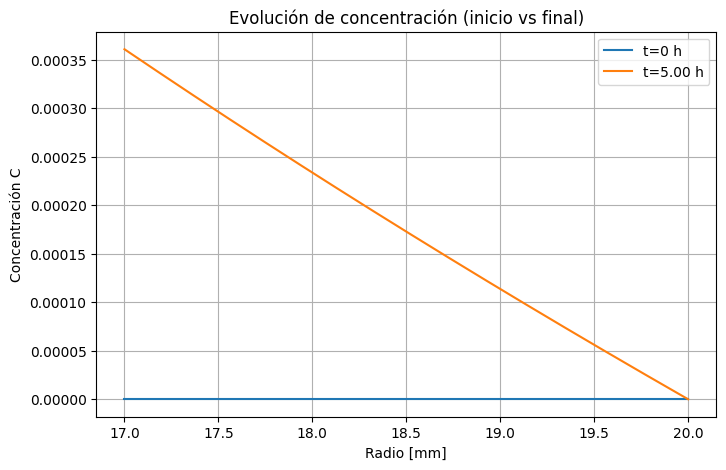

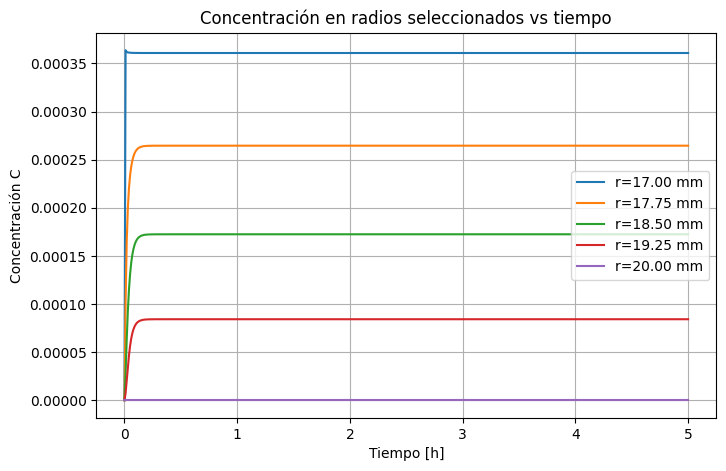

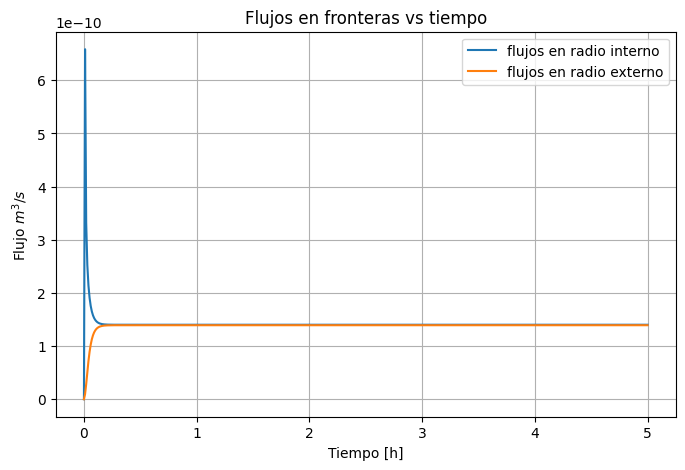

In [27]:
# ==============================
# 8. Gráficos
# ==============================

plt.figure(figsize=(8,5))
plt.plot(r*1e3, H[:,0], label="t=0 h")
plt.plot(r*1e3, H[:,-1], label=f"t={t_end_hours:.2f} h")
plt.xlabel("Radio [mm]")
plt.ylabel("Concentración C")
plt.legend()
plt.title("Evolución de concentración (inicio vs final)")
plt.grid(True)
plt.show()

# Concentración en varios radios vs tiempo
plt.figure(figsize=(8,5))
idxs = [0, n//4, n//2, 3*n//4, n-1]
for idx in idxs:
    plt.plot(tvec, H[idx, :], label=f"r={r[idx]*1e3:.2f} mm")
plt.xlabel("Tiempo [h]")
plt.ylabel("Concentración C")
plt.legend()
plt.title("Concentración en radios seleccionados vs tiempo")
plt.grid(True)
plt.show()

# Flujo en fronteras vs tiempo
plt.figure(figsize=(8,5))
plt.plot(tvec, Hflux[0, :], label='flujos en radio interno')
plt.plot(tvec, Hflux[-1, :], label='flujos en radio externo')
plt.xlabel("Tiempo [h]")
plt.ylabel("Flujo $m^3/s$")
plt.legend()
plt.title("Flujos en fronteras vs tiempo")
plt.grid(True)
plt.show()

# Resultados generados
El código produce gráficos de:
1. Concentración de H₂ vs radio para diferentes tiempos.
2. Evolución temporal de la concentración en radios específicos.
3. Flujo radial vs radio y flujos en las fronteras interna y externa.
4. Desplazamiento radial en función del radio.
5. Esfuerzos radiales (`σ_r`) y tangenciales (`σ_θ`).
6. Deformaciones radiales (`ε_r`) y tangenciales (`ε_θ`).

## Aplicaciones
Este modelo es útil para:
- Evaluar la permeabilidad y resistencia mecánica de materiales expuestos a hidrógeno.
- Estudiar problemas de **fragilización por hidrógeno** en componentes metálicos.
- Diseñar y validar estrategias de ingeniería para recipientes a presión y tuberías en presencia de gases reactivos.

# Anexo: Formulación Matemática del Modelo

# ANALISIS DE LAS GRAFICAS


1️⃣ Evolución de concentración (inicio vs final)

  **Curva azul (t=0 h):** prácticamente cero en todo el dominio → esto confirma que la condición inicial fue **C0=0** en todo el espesor, salvo el nodo interno que se actualiza en el primer paso.

  **Curva naranja (t=5 h):**

        - Tiene un gradiente lineal desde el radio interno (r=17.0r=17.0 mm) hasta el externo (r=20.0r=20.0 mm).

        - Esto indica que en 5 horas se alcanzó una solución casi estacionaria de la ecuación de difusión, donde la concentración se distribuye de forma estable entre las dos fronteras.

        - La pendiente es constante → difusión en estado estacionario para DD constante y condiciones de frontera fijas.

        

2️⃣ Concentración en radios seleccionados vs tiempo

  Todas las curvas suben rápidamente desde 0 y se estabilizan muy pronto (en menos de 0.5 h) → el tiempo característico de difusión es mucho menor que el tiempo total simulado.

  El valor final en cada radio es proporcional a su distancia a la frontera interna y externa:

        - Nodo más cercano al interno → concentración máxima.

        - Nodo más cercano al externo → concentración mínima (Cout).

  El hecho de que las curvas se mantengan planas después de ~0.5 h confirma que se llegó a estado estacionario muy rápido.

3️⃣ Qué significa físicamente

  Para los parámetros usados (**D=1×10−8 m2/sD=1×10−8 m2/s, espesor 3 mm**, condiciones fijas en las fronteras), el sistema alcanza el equilibrio de difusión en pocos minutos de tiempo físico.

    El perfil de concentración es casi lineal porque:

        No hay fuentes ni sumideros en el interior.

        El coeficiente de difusión es constante.

        Las fronteras se mantienen a valores fijos.

4️⃣ Implicaciones

  Si el objetivo es estudiar el proceso transitorio, necesitas:

       - Reducir DD o

       - Aumentar el espesor o

       - Usar un tiempo final más corto para capturar el periodo de transición.

  Si lo que se busca es el perfil estacionario, el código ya lo está calculando correctamente, pero 5 h es mucho más que el tiempo necesario para alcanzarlo.

## 1. Difusión de Hidrógeno

El transporte de hidrógeno en el material se modela mediante la **segunda ley de Fick** en coordenadas cilíndricas (simetría radial):

```
\[
\frac{\partial C(r,t)}{\partial t} = D \left[ \frac{1}{r} \frac{\partial}{\partial r} \left( r \frac{\partial C}{\partial r} \right) \right]
\]
```



donde:
- \( C(r,t) \) = concentración de hidrógeno [mol/m³]
- \( D \) = coeficiente de difusión [m²/s]
- \( r \) = coordenada radial [m]
- \( t \) = tiempo [s]

**Condiciones de frontera**:


```
\[
C(R_i,t) = C_{\text{in}}, \quad C(R_o,t) = C_{\text{out}}
\]
```



**Condición inicial**:


```
\[
C(r,0) = C_0
\]
```



---

## 2. Cálculo de Flujos Radiales

El flujo de hidrógeno se calcula a partir del **gradiente de concentración** usando la **primera ley de Fick**:



```
\[
J(r,t) = - D \frac{\partial C}{\partial r}
\]
```



El flujo total a través de un cilindro de radio \( r \) es:

```
\[
Q(r,t) = - 2\pi r \, D \, \frac{\partial C}{\partial r}
\]
```
---

## 3. Respuesta Mecánica: Elasticidad Lineal en Cilindros

El campo de desplazamientos \( u(r) \) se obtiene resolviendo la ecuación de equilibrio radial en coordenadas cilíndricas, considerando la expansión química inducida por la concentración (\( \Omega C \)):

```
\[
\frac{d^2 u}{dr^2} + \frac{1}{r} \frac{du}{dr} - \frac{u}{r^2} = -\frac{\Omega}{3(\nu - 1)} \frac{dC}{dr}
\]
```
donde:
- \( E \) = módulo de Young [Pa]
- \( \nu \) = coeficiente de Poisson [-]
- \( \Omega \) = coeficiente de expansión volumétrica [m³/mol]

---

## 4. Deformaciones y Esfuerzos

Las deformaciones radiales y tangenciales se calculan como:

```
\[
\varepsilon_r = \frac{du}{dr}, \quad \varepsilon_\theta = \frac{u}{r}
\]
```

Los esfuerzos radiales (\( \sigma_r \)) y tangenciales (\( \sigma_\theta \)) se obtienen mediante la **ley de Hooke** modificada para incluir el efecto de concentración:

```
\[
\sigma_r = \frac{E}{(1+\nu)(2\nu - 1)} \left[ (\nu - 1)\varepsilon_r - \nu \varepsilon_\theta + \frac{\Omega}{3} C \right]
\]
```
```
\[
\sigma_\theta = \frac{E}{(1+\nu)(2\nu - 1)} \left[ (\nu - 1)\varepsilon_\theta - \nu \varepsilon_r + \frac{\Omega}{3} C \right]
\]
```
---

## 5. Método Numérico

- **Discretización espacial**: diferencias finitas en malla radial uniforme de \( n \) nodos.
- **Esquema temporal**: implícito (Crank–Nicolson en este caso simplificado) que garantiza estabilidad numérica.
- **Resolución de sistemas**: `solve_banded` de SciPy para aprovechar la estructura de banda de las matrices.

---

## Recomendación para visualizar más dinámica en la simulación

En la configuración actual, el tiempo característico de difusión es mucho menor que el tiempo total simulado, por lo que el sistema alcanza el equilibrio muy rápido y la parte transitoria apenas se aprecia.

El tiempo característico de difusión puede estimarse como:

\[
t_\text{difusión} \approx \frac{L^2}{D}
\]

donde:
- \( L \) es el espesor del cilindro (\( 3\ \text{mm} \)),
- \( D \) es el coeficiente de difusión.

Con \( D = 1\times10^{-8} \ \text{m}^2/s \) y \( L = 3\times10^{-3} \ \text{m} \):

\[
t_\text{difusión} \approx \frac{(3\times10^{-3})^2}{10^{-8}} = 900\ \text{s} \ (\approx 0.25\ \text{h})
\]

Esto explica por qué el sistema se estabiliza antes de 0.5 h en las gráficas.

**Para visualizar una evolución más lenta y con mayor detalle de la fase transitoria**, se recomienda:
- Reducir el valor de \( D \), por ejemplo a \( 1\times10^{-10} \ \text{m}^2/s \).
- Mantener el tiempo total simulado (5 h o más).
- Ajustar el número de pasos de tiempo para preservar la estabilidad y la resolución temporal.

Con \( D = 1\times10^{-10} \ \text{m}^2/s \), el tiempo característico de difusión sería:

\[
t_\text{difusión} \approx \frac{(3\times10^{-3})^2}{10^{-10}} = 90{,}000\ \text{s} \ (\approx 25\ \text{h})
\]

Esto permitiría observar gradualmente cómo la concentración evoluciona desde el estado inicial hasta el estado estacionario.
